In [5]:
# Grid Search or Random Search for optimizing k in K-Means
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
import numpy as np
from pyspark.ml.clustering import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from src.config.spark_session import get_spark_session

spark = get_spark_session()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/24 16:21:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [7]:

rfm_scaled = spark.read.parquet(
    "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/processed/rfm_scaled/*"
)

rfm_scaled.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = true)
 |-- Monetary: double (nullable = true)
 |-- Log_Frequency: double (nullable = true)
 |-- Log_Monetary: double (nullable = true)
 |-- RFM_Score: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)



In [8]:
# Function to calculate Euclidean distance squared
def squared_euclidean_distance(point, center):
    return float(np.sum((np.array(point) - np.array(center)) ** 2))

# Register the function as a UDF
squared_distance_udf = udf(squared_euclidean_distance, DoubleType())

In [9]:
# Define a range of k values for testing
k_values = range(2, 11)

# Initialize K-Means models for different k values
evaluation_metrics = []

for k in k_values:
    kmeans = KMeans(k=k, seed=42, featuresCol="scaledFeatures", predictionCol="cluster")
    kmeans_model = kmeans.fit(rfm_scaled)
    rfm_clusters = kmeans_model.transform(rfm_scaled)

    # Get cluster centers
    cluster_centers = kmeans_model.clusterCenters()

    # Add a column for squared Euclidean distance to the cluster center
    def calculate_wcss(row):
        cluster_center = cluster_centers[row['cluster']]
        return squared_euclidean_distance(row['scaledFeatures'], cluster_center)

    # Apply the WCSS function to calculate squared distances
    rfm_clusters = rfm_clusters.withColumn("squared_distance", F.udf(lambda row: calculate_wcss(row), DoubleType())(F.struct("scaledFeatures", "cluster")))

    # Calculate WCSS (sum of squared distances)
    wcss = rfm_clusters.agg(F.sum("squared_distance")).collect()[0][0]

    # Evaluate Silhouette Score
    evaluator_silhouette = ClusteringEvaluator(featuresCol="scaledFeatures", predictionCol="cluster", metricName="silhouette")
    silhouette_score = evaluator_silhouette.evaluate(rfm_clusters)

    # Append results to the list
    evaluation_metrics.append({
        "k": k,
        "WCSS": wcss,
        "SilhouetteScore": silhouette_score
    })

# Convert the results to a pandas DataFrame
metrics_df = pd.DataFrame(evaluation_metrics)

# Display the results
display(metrics_df)

25/12/24 16:22:07 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


,k,WCSS,SilhouetteScore
0,2,9081.875263,0.659210
1,3,5332.151945,0.609236
2,4,4501.287229,0.548341
3,5,3507.144381,0.526787
4,6,3238.175083,0.536512
5,7,2909.648742,0.528136
6,8,2537.473388,0.480448
7,9,2466.778406,0.397572
8,10,2221.950727,0.406004


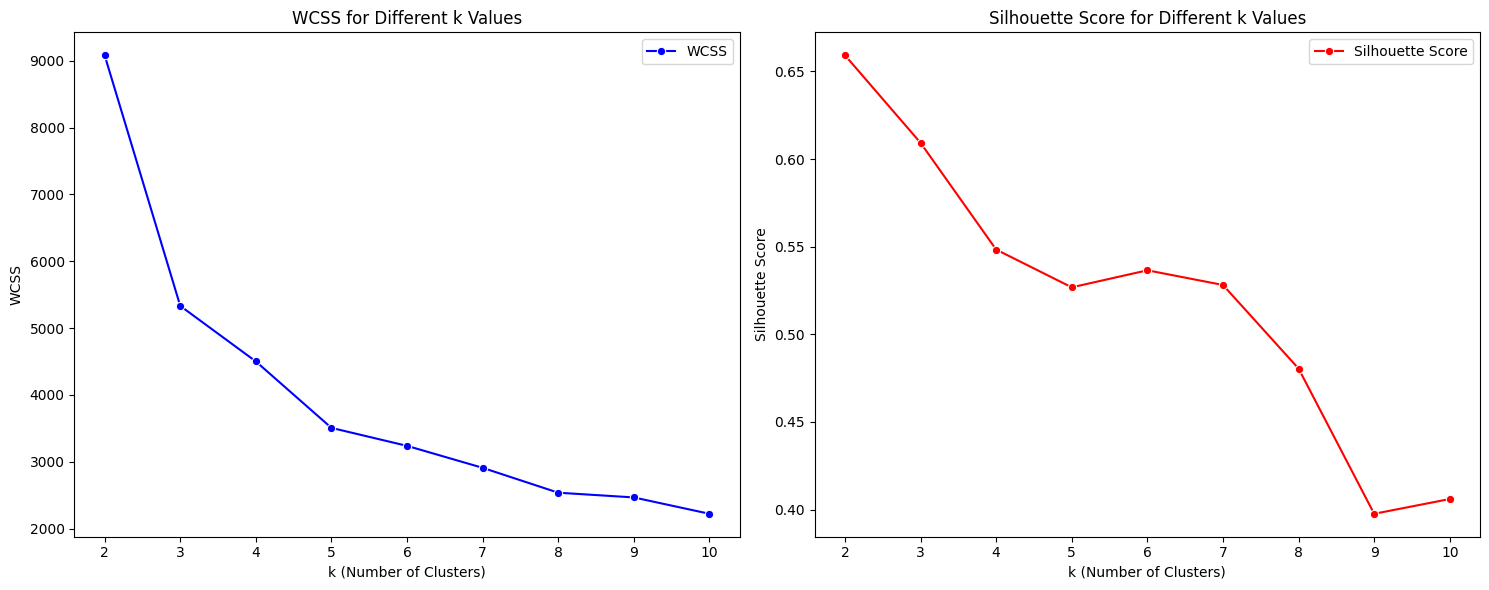

In [10]:
# Plot WCSS and Silhouette Score comparisons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot WCSS values
sns.lineplot(x='k', y='WCSS', data=metrics_df, ax=ax1, marker='o', color='b', label='WCSS')
ax1.set_title('WCSS for Different k Values')
ax1.set_xlabel('k (Number of Clusters)')
ax1.set_ylabel('WCSS')

# Plot Silhouette Scores
sns.lineplot(x='k', y='SilhouetteScore', data=metrics_df, ax=ax2, marker='o', color='r', label='Silhouette Score')
ax2.set_title('Silhouette Score for Different k Values')
ax2.set_xlabel('k (Number of Clusters)')
ax2.set_ylabel('Silhouette Score')

# Display the plots
plt.tight_layout()
plt.show()

In [11]:
# Select the best k based on silhouette scores or elbow curve
best_k = 3

print('The optimal number of clusters:', best_k)

# Fit KMeans with the optimal k
kmeans = KMeans(k=best_k, seed=42, featuresCol="scaledFeatures", predictionCol="cluster")
kmeans_model = kmeans.fit(rfm_scaled)
rfm_clusters = kmeans_model.transform(rfm_scaled)

rfm_clusters_df = pd.DataFrame(rfm_clusters.groupBy("cluster").count().toPandas())
display(rfm_clusters_df)

The optimal number of clusters: 3


,cluster,count
0,1,984
1,2,1986
2,0,1361


In [12]:
# Visualize cluster distributions
print("Shape of the DataFrame:", (rfm_clusters.count(), len(rfm_clusters.columns)))
rfm_clusters.select("CustomerID", "Recency", "Log_Frequency", "Log_Monetary", "cluster").show(10)

Shape of the DataFrame: (4331, 10)
+----------+-------+------------------+------------------+-------+
|CustomerID|Recency|     Log_Frequency|      Log_Monetary|cluster|
+----------+-------+------------------+------------------+-------+
|     16503|    106| 1.791759469228055|7.2601219556508365|      0|
|     16339|    284|0.6931471805599453| 4.709079649378603|      1|
|     12626|     23|2.6390573296152584| 8.762387820757855|      0|
|     14423|    218|0.6931471805599453|5.5842479059610115|      1|
|     17809|     16| 2.772588722239781| 8.440014046497208|      0|
|     13483|     65|0.6931471805599453| 4.951168335262708|      2|
|     17754|      0|1.9459101490553132| 7.462168988109326|      0|
|     14837|     89| 1.791759469228055| 7.403792085274688|      0|
|     16283|      5|2.0794415416798357| 7.334662193074558|      0|
|     17783|     72|1.0986122886681096| 5.650627799851681|      2|
+----------+-------+------------------+------------------+-------+
only showing top 10 rows



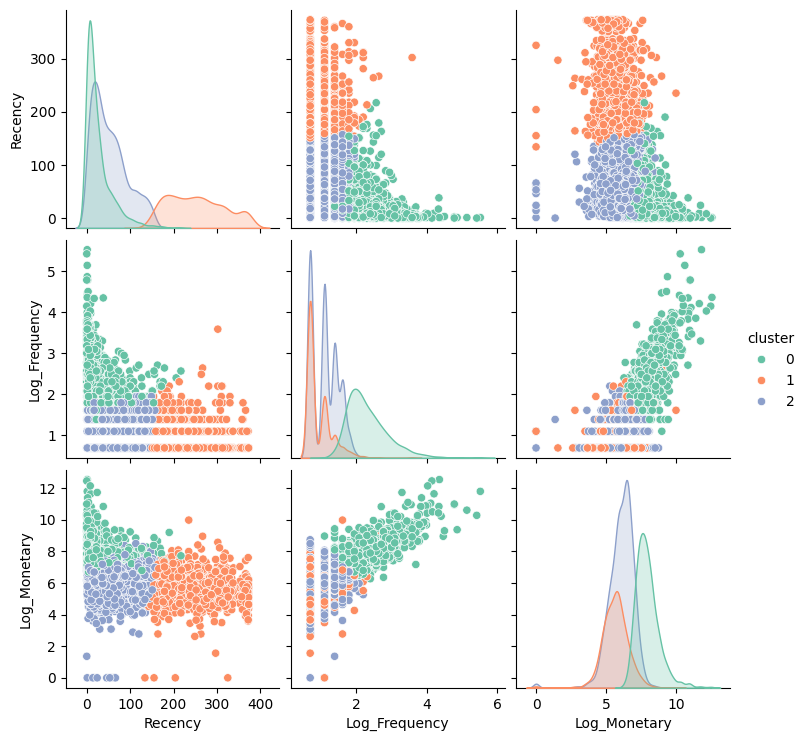

In [13]:
# Convert PySpark DataFrame to Pandas for visualization
rfm_pd = rfm_clusters.select("Recency", "Log_Frequency", "Log_Monetary", "cluster").toPandas()

# Pairplot for cluster visualization
sns.pairplot(rfm_pd, hue="cluster", diag_kind="kde", palette="Set2")
plt.show()

In [14]:
# Mean RFM Values per Cluster
# Calculate mean RFM metrics per cluster
mean_rfm_per_cluster = rfm_clusters.groupBy("cluster").agg(
    F.avg("Recency").alias("Mean_Recency"),
    F.avg("Log_Frequency").alias("Mean_Frequency"),
    F.avg("Log_Monetary").alias("Mean_Monetary"),
    F.avg("RFM_Score").alias("Mean_RFM_Score")
)

mean_rfm_per_cluster_df = pd.DataFrame(mean_rfm_per_cluster.toPandas())
display(mean_rfm_per_cluster_df)

,cluster,Mean_Recency,Mean_Frequency,Mean_Monetary,Mean_RFM_Score
0,1,252.039634,0.934215,5.639840,258.613689
1,2,52.975831,1.109263,6.063140,60.148234
2,0,26.538575,2.314800,7.923159,36.776534


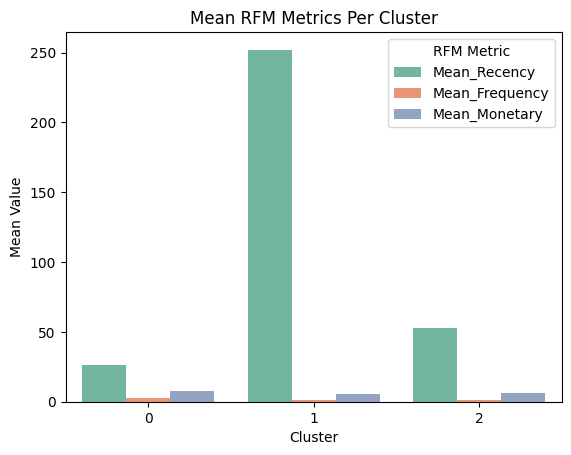

In [15]:
# Visualize Mean RFM Values per Cluster
mean_rfm_pd = mean_rfm_per_cluster.toPandas()
mean_rfm_pd_melted = mean_rfm_pd.melt(id_vars=["cluster"],
                                      value_vars=["Mean_Recency", "Mean_Frequency", "Mean_Monetary"],
                                      var_name="Metric", value_name="Value")

sns.barplot(x="cluster", y="Value", hue="Metric", data=mean_rfm_pd_melted, palette="Set2")
plt.title("Mean RFM Metrics Per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Value")
plt.legend(title="RFM Metric")
plt.show()

In [16]:

# Collecting mean RFM score for each cluster
mean_rfm_dict = mean_rfm_per_cluster.collect()
mean_rfm_dict = {row['cluster']: row['Mean_RFM_Score'] for row in mean_rfm_dict}

display(mean_rfm_dict)

{1: 258.6136886622861, 2: 60.14823354470212, 0: 36.77653374708975}

In [17]:
from pyspark.sql.types import IntegerType, FloatType, DoubleType, StringType
from pyspark.sql.functions import col
# Function to label customers based on RFM score
def label_customer(rfm_score, mean_rfm_score):
    if rfm_score > mean_rfm_score * 1.2:  # Elite if score is significantly higher
        return "Elite"
    elif rfm_score < mean_rfm_score * 0.8:  # Dormant if score is significantly lower
        return "Dormant"
    else:  # Standard customers are in the middle range
        return "Standard"

# Register the function as a UDF
label_udf = F.udf(lambda rfm_score, cluster: label_customer(rfm_score, mean_rfm_dict[cluster]), StringType())

# Apply the UDF to label each customer
rfm_clusters = rfm_clusters.withColumn("Customer_Type", label_udf(col("RFM_Score"), col("cluster")))

# Show labeled customers
rfm_clusters.select("CustomerID", "RFM_Score", "cluster", "Customer_Type").show(10)

+----------+------------------+-------+-------------+
|CustomerID|         RFM_Score|cluster|Customer_Type|
+----------+------------------+-------+-------------+
|     16503|115.05188142487889|      0|        Elite|
|     16339|289.40222682993857|      1|     Standard|
|     12626|34.401445150373114|      0|     Standard|
|     14423|224.27739508652095|      1|     Standard|
|     17809| 27.21260276873699|      0|      Dormant|
|     13483| 70.64431551582265|      2|     Standard|
|     17754|  9.40807913716464|      0|      Dormant|
|     14837| 98.19555155450274|      0|        Elite|
|     16283|14.414103734754395|      0|      Dormant|
|     17783| 78.74924008851978|      2|        Elite|
+----------+------------------+-------+-------------+
only showing top 10 rows



In [18]:
# Calculate the count of each type of customer per cluster
display(rfm_clusters.groupBy("cluster", "Customer_Type").count().toPandas().sort_values(by='count', ascending=False))


,cluster,Customer_Type,count
0,2,Dormant,938
3,0,Dormant,770
8,2,Elite,658
7,1,Standard,482
4,2,Standard,390
2,0,Elite,344
5,1,Dormant,265
6,0,Standard,247
1,1,Elite,237


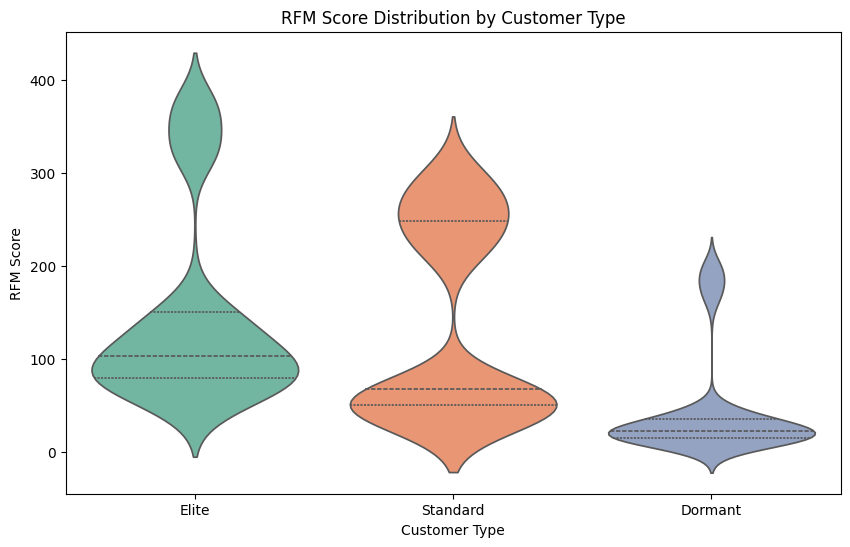

In [19]:
# Convert the Spark DataFrame to Pandas for visualization
rfm_pd = rfm_clusters.select("RFM_Score", "Customer_Type").toPandas()

# Create a violin plot to visualize the distribution of RFM scores across customer types
plt.figure(figsize=(10, 6))
sns.violinplot(x="Customer_Type", y="RFM_Score", data=rfm_pd, inner="quart", palette='Set2', hue="Customer_Type")
plt.title('RFM Score Distribution by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('RFM Score')
plt.show()

In [21]:
rfm_clusters.printSchema()
rfm_clusters.show(10)

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = true)
 |-- Monetary: double (nullable = true)
 |-- Log_Frequency: double (nullable = true)
 |-- Log_Monetary: double (nullable = true)
 |-- RFM_Score: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- cluster: integer (nullable = false)
 |-- Customer_Type: string (nullable = true)

+----------+-------+---------+------------------+------------------+------------------+------------------+--------------------+--------------------+-------+-------------+
|CustomerID|Recency|Frequency|          Monetary|     Log_Frequency|      Log_Monetary|         RFM_Score|            features|      scaledFeatures|cluster|Customer_Type|
+----------+-------+---------+------------------+------------------+------------------+------------------+--------------------+--------------------+-------+-------------+
|     16503|    1

In [22]:
output_path = "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/processed/rfm_clusters"

rfm_clusters.write.mode("overwrite").parquet(output_path)

25/12/25 02:43:55 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3173245 ms exceeds timeout 120000 ms
25/12/25 02:43:55 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/25 02:43:56 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$